# 05 C++ simulator & reactive strategies

Phase 4c. Two questions:

1. **Engineering:** is the C++ port (pybind11) *identical* to the Python reference, how much
   faster is it, and what do zero-copy and GIL release buy us in practice?
2. **Strategy:** a fixed plan only gets a cheap Safety Car stop by luck. Does a policy that
   **reacts** to the Safety Car beat the best fixed strategy, and by how much?

All runs use `reference_race()`: a Bahrain-like race with Pirelli-style tyres (see `race_model.py`
for why we don't use the data-fitted parameters here).

> Build the module first: `.venv/bin/python -m src.cpp.build`

In [1]:
# Run from the repo root so `import src...` works.
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
sys.path.insert(0, str(Path.cwd()))

import time
from concurrent.futures import ThreadPoolExecutor
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.cpp import sim
from src.models.baselines import monte_carlo as mc
from src.models.baselines.race_model import reference_race
from src.models.baselines.reactive import (ReactivePolicy, enumerate_reactive_policies,
                                           evaluate_policies, simulate_reactive_py)

pd.set_option("display.max_columns", 40, "display.width", 200)
plt.rcParams.update({
    "figure.figsize": (11, 4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titleweight": "bold", "axes.titlesize": 12, "lines.linewidth": 2,
    "legend.frameon": False,
})
PY, NP, CPP, GOOD, MUTED, INK = "#eb6834", "#1baf7a", "#2a78d6", "#2a78d6", "#8a8984", "#0b0b0b"

params = reference_race()
rng = np.random.default_rng(0)
N = 4000
sc_mask = mc.draw_safety_car(rng, N, params.total_laps, params.sc_hazard_per_lap, params.sc_duration_laps)
noise = mc.draw_lap_noise(rng, N, params)
print(f"{params.total_laps} laps, compounds {params.compounds}, {N:,} simulated races "
      f"({sc_mask.any(axis=1).mean():.0%} with at least one Safety Car)")

57 laps, compounds ('SOFT', 'MEDIUM', 'HARD'), 4,000 simulated races (54% with at least one Safety Car)


## 1 Parity: C++ must equal Python, number for number

A port is only useful if it computes **the same thing**. Here, every simulated race of a
reactive policy, Python vs C++.

**What to look for**
* All points on the diagonal; a maximum absolute difference around **1e-11 s** or less
  (floating-point rounding, not a logic difference).

reactive  max |Python - C++| = 1.82e-12 s
static    max |NumPy  - C++| = 5.46e-12 s


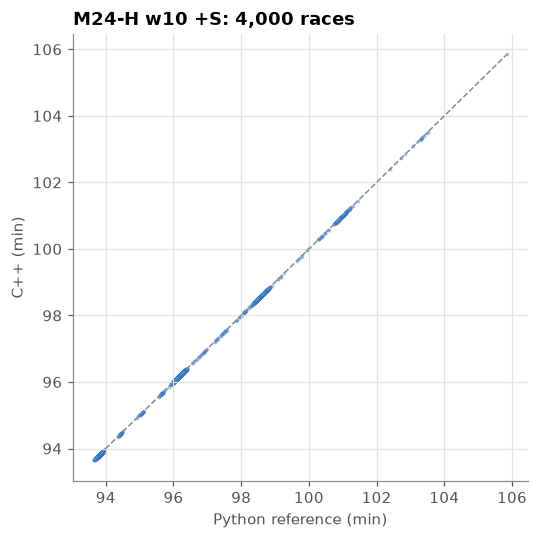

In [2]:
policy = ReactivePolicy("MEDIUM", "HARD", 24, sc_window=10, extra_compound="SOFT", extra_min_age=12, extra_min_laps_left=10)
py_times = simulate_reactive_py(policy, params, sc_mask, noise)
cpp_times = sim.simulate_reactive_cpp(policy, params, sc_mask, noise)
static = mc.Strategy((("MEDIUM", 24), ("HARD", 33)))
np_static, cpp_static = mc.simulate_race_times(static, params, sc_mask, noise), sim.simulate_race_times_cpp(static, params, sc_mask, noise)

print(f"reactive  max |Python - C++| = {np.abs(py_times - cpp_times).max():.2e} s")
print(f"static    max |NumPy  - C++| = {np.abs(np_static - cpp_static).max():.2e} s")
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(py_times / 60, cpp_times / 60, s=6, alpha=0.4, color=CPP, linewidth=0)
lims = [py_times.min() / 60, py_times.max() / 60]
ax.plot(lims, lims, color=MUTED, linewidth=1, linestyle="--")
ax.set_xlabel("Python reference (min)"); ax.set_ylabel("C++ (min)")
ax.set_title(f"{policy.name}: {N:,} races", loc="left")
plt.tight_layout()

## 2 Speed

Same work, four implementations:

| | What runs per lap | Why it's that fast / slow |
|---|---|---|
| Python reference | interpreter executes every line, for every sim and lap | each `+`, `if`, dict lookup is a few dozen machine-level operations plus type checks |
| NumPy (fixed strategies only) | one array operation over all sims at once | the loop runs in compiled C inside NumPy, but every step allocates a temporary array |
| C++ reactive | compiled loop, branch per sim | no interpreter, no temporaries, data stays in registers / cache |
| C++ batch | one call for the whole policy grid | also skips the Python->C++ call overhead per policy |

**What to look for**
* Python reference: tens of milliseconds per policy. C++: a fraction of a millisecond.
* NumPy is fast for **fixed** strategies, but it cannot express the reactive policy at all
  without a Python loop over laps with masks.

In [3]:
def best_time(fn, repeat=5):
    times = []
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); times.append(time.perf_counter() - t0)
    return min(times)  # min: least disturbed by other processes

grid = enumerate_reactive_policies(params, sc_windows=(0, 4, 8, 12), extra_compounds=(None, "SOFT"))
rows = [
    ("Python reference, 1 reactive policy", best_time(lambda: simulate_reactive_py(policy, params, sc_mask, noise), 1)),
    ("NumPy, 1 fixed strategy", best_time(lambda: mc.simulate_race_times(static, params, sc_mask, noise))),
    ("C++, 1 fixed strategy", best_time(lambda: sim.simulate_race_times_cpp(static, params, sc_mask, noise))),
    ("C++, 1 reactive policy", best_time(lambda: sim.simulate_reactive_cpp(policy, params, sc_mask, noise))),
    (f"C++ batch, {len(grid):,} reactive policies", best_time(lambda: sim.simulate_reactive_batch_cpp(grid, params, sc_mask, noise), 2)),
]
speed = pd.DataFrame(rows, columns=["implementation", "seconds"])
speed["per policy (ms)"] = speed["seconds"] * 1000 / np.where(speed["implementation"].str.contains("batch"), len(grid), 1)
py_per = speed.loc[0, "per policy (ms)"]
speed["speedup vs Python"] = py_per / speed["per policy (ms)"]
print(f"{N:,} races x {params.total_laps} laps each")
speed.round(4)

4,000 races x 57 laps each


,implementation,seconds,per policy (ms),speedup vs Python
0,"Python reference, 1 reactive policy",0.0677,67.7039,1.0000
1,"NumPy, 1 fixed strategy",0.0009,0.9415,71.9074
2,"C++, 1 fixed strategy",0.0003,0.3332,203.1882
3,"C++, 1 reactive policy",0.0003,0.2910,232.6258
4,"C++ batch, 2,016 reactive policies",0.5556,0.2756,245.6678


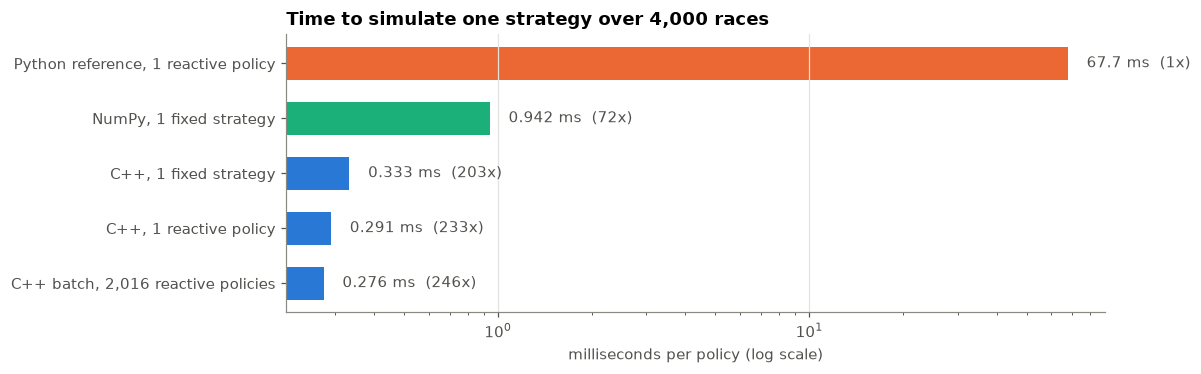

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.5))
colors = [PY, NP, CPP, CPP, CPP]
ax.barh(speed["implementation"], speed["per policy (ms)"], color=colors, height=0.6)
ax.set_xscale("log"); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
for y, (ms, x) in enumerate(zip(speed["per policy (ms)"], speed["speedup vs Python"])):
    ax.text(ms * 1.15, y, f"{ms:.3g} ms  ({x:,.0f}x)", va="center", color="#52514e")
ax.set_xlabel("milliseconds per policy (log scale)")
ax.set_title(f"Time to simulate one strategy over {N:,} races", loc="left")
plt.tight_layout()

## 3 Zero-copy in practice

`py::array_t<double, c_style | forcecast>` hands C++ a pointer to **NumPy's own memory** when
the array is already C-ordered `float64`. Otherwise pybind11 silently makes a converted copy first.
The result is identical either way (the parity tests check that), but the copy costs time.

**What to look for**
* C-ordered float64 is the fastest. Fortran order or float32 add the cost of a full copy of
  `noise` and `sc_mask` before any simulation runs. Results are equal in all three cases.

In [5]:
variants = {
    "C-ordered float64 (zero copy)": (sc_mask, noise),
    "Fortran-ordered (copied)": (np.asfortranarray(sc_mask), np.asfortranarray(noise)),
    "float32 noise (converted)": (sc_mask, noise.astype(np.float32)),
}
base = sim.simulate_reactive_cpp(policy, params, sc_mask, noise)
rows = []
for name, (sc_v, nz_v) in variants.items():
    out = sim.simulate_reactive_cpp(policy, params, sc_v, nz_v)
    rows.append({"input": name, "C_contiguous": nz_v.flags["C_CONTIGUOUS"], "dtype": str(nz_v.dtype),
                 "ms": 1000 * best_time(lambda: sim.simulate_reactive_cpp(policy, params, sc_v, nz_v), 20),
                 "max |diff| vs zero-copy (s)": np.abs(out - base).max()})
zc = pd.DataFrame(rows)
zc["ms"] = zc["ms"].round(3)
zc["max |diff| vs zero-copy (s)"] = zc["max |diff| vs zero-copy (s)"].map("{:.1e}".format)
zc

,input,C_contiguous,dtype,ms,max |diff| vs zero-copy (s)
0,C-ordered float64 (zero copy),True,float64,0.289,0.0e+00
1,Fortran-ordered (copied),False,float64,0.508,0.0e+00
2,float32 noise (converted),True,float32,0.371,3.1e-07


float32 noise gives slightly different totals: the noise values themselves were rounded to
float32 **before** C++ saw them. Zero-copy matters for correctness too: you know exactly which
numbers the C++ code reads.

## 4 Releasing the GIL: real parallelism from Python threads

Python threads normally can't run Python code in parallel (the Global Interpreter Lock). Our
C++ core runs **without** the GIL (`py::gil_scoped_release`), so several threads can each run a
batch on a different CPU core at the same time.

**What to look for**
* Wall time drops as threads are added (up to your number of performance cores), even though
  this is plain `ThreadPoolExecutor`, no multiprocessing.

CPU cores available: 8


,threads,seconds,speedup
0,1,0.557,1.000
1,2,0.317,1.754
2,4,0.170,3.284
3,8,0.118,4.711


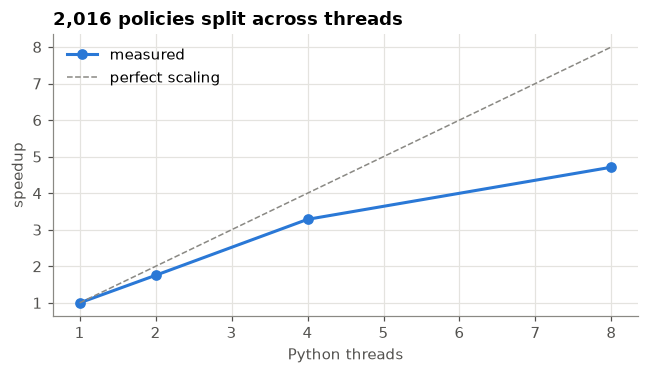

In [6]:
chunks = lambda k: [grid[i::k] for i in range(k)]
rows = []
for k in [1, 2, 4, 8]:
    def run(k=k):
        with ThreadPoolExecutor(max_workers=k) as pool:
            list(pool.map(lambda ps: sim.simulate_reactive_batch_cpp(ps, params, sc_mask, noise), chunks(k)))
    rows.append({"threads": k, "seconds": best_time(run, 2)})
threads = pd.DataFrame(rows)
threads["speedup"] = threads.loc[0, "seconds"] / threads["seconds"]
print(f"CPU cores available: {os.cpu_count()}")
display(threads.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(threads["threads"], threads["speedup"], marker="o", color=CPP, label="measured")
ax.plot(threads["threads"], threads["threads"], linestyle="--", color=MUTED, linewidth=1, label="perfect scaling")
ax.set_xlabel("Python threads"); ax.set_ylabel("speedup"); ax.legend()
ax.set_title(f"{len(grid):,} policies split across threads", loc="left")
plt.tight_layout()

## 5 Fixed vs reactive: does reacting to the Safety Car pay?

Best fixed strategy (every 1–2 stop plan) vs the best reactive policy from a grid of plan laps,
SC windows and an optional extra stop. **Same 4,000 races for both** (common random numbers).

**What to look for**
* The best reactive policy beats the best fixed plan on average.
* In races **without** a Safety Car the gain is close to zero: the policy just follows its plan
  (slightly negative here, because the best reactive plan stops a couple of laps later than the
  best fixed one). The gain comes from races **with** a Safety Car **inside the reaction window**;
  an SC at any other time changes nothing.

In [7]:
fixed = mc.evaluate_strategies(mc.enumerate_strategies(params, 2, 8), params, n_sims=N, seed=0)
t0 = time.perf_counter()
reactive = evaluate_policies(grid, params, simulate=sim.simulate_reactive_cpp, n_sims=N, seed=0)
print(f"{len(grid):,} reactive policies evaluated in {time.perf_counter() - t0:.1f} s")
best_fixed, best_reactive = fixed.iloc[0], reactive.iloc[0]
print(f"best fixed    : {best_fixed['strategy']:<14} mean {best_fixed['mean_s']:.2f} s")
print(f"best reactive : {best_reactive['policy']:<14} mean {best_reactive['mean_s']:.2f} s")
print(f"average gain  : {best_fixed['mean_s'] - best_reactive['mean_s']:.2f} s per race")
reactive.head(8).round(2)

2,016 reactive policies evaluated in 0.7 s
best fixed    : M24-H33        mean 5732.63 s
best reactive : M26-H w12      mean 5732.10 s
average gain  : 0.52 s per race


,policy,mean_s,std_s,p05_s,p95_s,delta_to_best_s
0,M26-H w12,5732.10,115.40,5624.80,5922.06,0.00
1,M25-H w8,5732.12,115.56,5624.69,5921.93,0.01
2,M26-H w8,5732.15,115.48,5624.80,5922.10,0.05
3,M25-H w12,5732.16,115.59,5624.69,5921.92,0.06
4,M24-H w8,5732.20,115.60,5624.70,5921.98,0.09
5,M27-H w12,5732.20,115.29,5625.03,5922.25,0.10
6,M26-H w12 +S,5732.22,115.53,5624.80,5923.54,0.12
7,H33-M w8 +S,5732.23,115.61,5624.70,5921.47,0.13


no SC: mean gain -0.10 s | with SC: mean gain +1.05 s, reactive faster in 27% of SC races


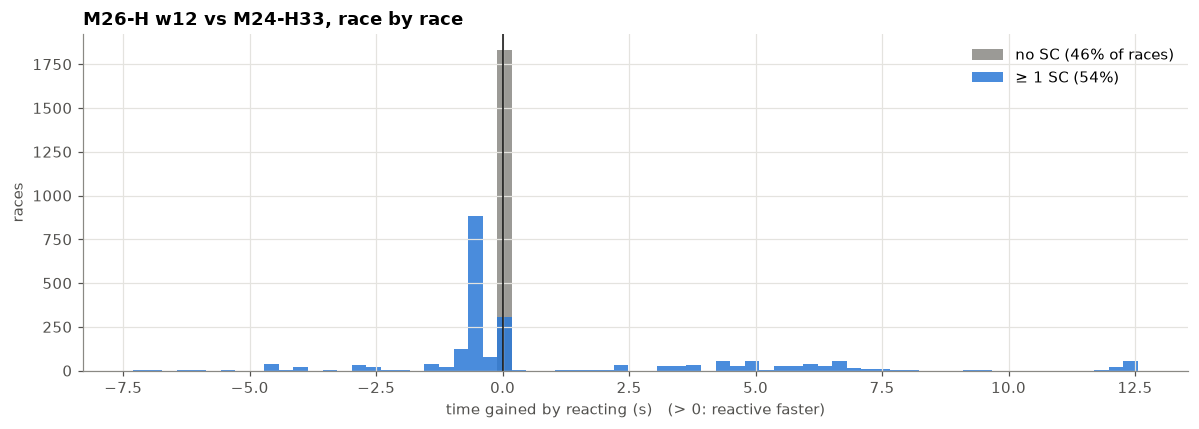

In [8]:
# Per-race gain of the best reactive policy over the best fixed strategy.
by_name_fixed = {s.name: s for s in mc.enumerate_strategies(params, 2, 8)}
by_name_reactive = {p.name: p for p in grid}
t_fixed = mc.simulate_race_times(by_name_fixed[best_fixed["strategy"]], params, sc_mask, noise)
t_react = sim.simulate_reactive_cpp(by_name_reactive[best_reactive["policy"]], params, sc_mask, noise)
gain = t_fixed - t_react
had_sc = sc_mask.any(axis=1)

fig, ax = plt.subplots()
bins = np.linspace(np.percentile(gain, 0.5), np.percentile(gain, 99.5), 70)
ax.hist(gain[~had_sc], bins=bins, color=MUTED, alpha=0.85, label=f"no SC ({(~had_sc).mean():.0%} of races)")
ax.hist(gain[had_sc], bins=bins, color=GOOD, alpha=0.85, label=f"≥ 1 SC ({had_sc.mean():.0%})")
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlabel("time gained by reacting (s)   (> 0: reactive faster)"); ax.set_ylabel("races"); ax.legend()
ax.set_title(f"{best_reactive['policy']} vs {best_fixed['strategy']}, race by race", loc="left")
plt.tight_layout()
print(f"no SC: mean gain {gain[~had_sc].mean():+.2f} s | with SC: mean gain {gain[had_sc].mean():+.2f} s, "
      f"reactive faster in {(gain[had_sc] > 0).mean():.0%} of SC races")

## 6 More Safety Cars: fixed vs reactive

Notebook 04 showed that more Safety Cars make a **fixed** 2-stop worse. For a reactive policy
the opposite should happen: more SCs = more chances for a cheap stop.

**What to look for**
* The reactive advantage over the best fixed plan **grows** with the SC hazard.

,hazard,best_fixed,best_reactive,reactive_gain_s
0,0.000,H32-M25,H32-M w12,0.000
1,0.007,H32-M25,M25-H w12,0.272
2,0.014,H32-M25,M26-H w12,0.605
3,0.030,H32-M25,H35-M w12 +S,1.119
4,0.050,H32-M25,M28-H w12,1.933


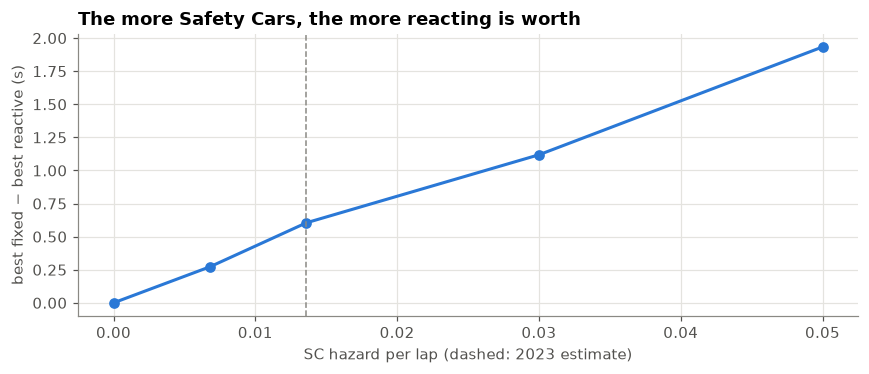

In [9]:
fixed_grid = mc.enumerate_strategies(params, 2, 8, step=2)
rows = []
for hazard in [0.0, 0.0068, params.sc_hazard_per_lap, 0.03, 0.05]:
    p = replace(params, sc_hazard_per_lap=hazard)
    f = mc.evaluate_strategies(fixed_grid, p, n_sims=2000, seed=1)
    r = evaluate_policies(grid, p, simulate=sim.simulate_reactive_cpp, n_sims=2000, seed=1)
    rows.append({"hazard": hazard, "best_fixed": f.iloc[0]["strategy"], "best_reactive": r.iloc[0]["policy"],
                 "reactive_gain_s": f.iloc[0]["mean_s"] - r.iloc[0]["mean_s"]})
sens = pd.DataFrame(rows)
display(sens.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sens["hazard"], sens["reactive_gain_s"], marker="o", color=GOOD)
ax.axvline(params.sc_hazard_per_lap, color=MUTED, linestyle="--", linewidth=1)
ax.set_xlabel("SC hazard per lap (dashed: 2023 estimate)"); ax.set_ylabel("best fixed − best reactive (s)")
ax.set_title("The more Safety Cars, the more reacting is worth", loc="left")
plt.tight_layout()

## Takeaways

1. **Parity first, speed second.** The C++ port reproduces the Python reference to ~1e-11 s, so
   every speed number above is for *the same computation*.
2. **C++ is ~hundreds of times faster than plain Python** for branching, per-simulation logic,
   and still faster than NumPy for the fixed strategies NumPy *can* vectorise. Releasing the GIL
   adds multi-core parallelism from ordinary Python threads.
3. **Reacting beats planning.** The best reactive policy wins on average, and all of its gain
   comes from races with a Safety Car. Its value grows with the SC rate, the exact opposite of a
   fixed 2-stop.
4. These policies are **hand-designed rules** with a handful of parameters. Phase 4d asks whether
   a reinforcement-learning agent, deciding lap by lap from the race state, can find something
   better than the best rule.